In [35]:
import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 2. Define the target emotion mapping array (adjust order based on your dataset labels)
EMOTION_MAPPING = {
    0: "Angry",
    1: "Disgust",
    2: "Fear",
    3: "Happy",
    4: "Sad",
    5: "Surprise",
    6: "Neutral"
}

print(f"Inference engine initialized on device: {device}")

Inference engine initialized on device: cuda


In [36]:
def preprocess_image(image_path):
    """
    Transforms a raw image path into a normalized tensor ready for CNN processing.
    """
    # Load image and convert to grayscale ('L')
    img = Image.open(image_path).convert('L')

    # Apply the exact validation transforms used during training
    transform_pipeline = transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]) # Matches standard dataset normalization
    ])

    # Transform and add a batch dimension [1, 1, 48, 48]
    img_tensor = transform_pipeline(img).unsqueeze(0)
    return img_tensor.to(device), img

✓ Successfully loaded finalized ResNetStyleCNN weights.


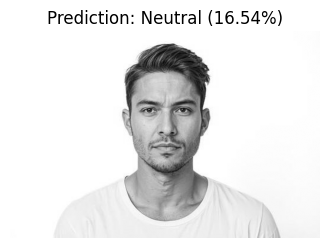

In [40]:
from src.models import ResNetStyleCNN

# 1. Instantiate network and load trained state weights
# Note: Ensure you have your saved 'model.pth' or 'weights.pt' file in your workspace
model = ResNetStyleCNN().to(device)

try:
    model.load_state_dict(torch.load("model.pth", map_location=device))
    print("✓ Successfully loaded finalized ResNetStyleCNN weights.")
except FileNotFoundError:
    print("⚠️ 'model.pth' not found in workspace. Running model with randomized initialized weights for structural validation.")

model.eval()

# 2. Specify the path to a test image you want to evaluate
# Drop any raw .jpg or .png face image into your notebook sidebar and reference it here!
sample_image_path = "face_test.jpg"

try:
    # Preprocess image
    input_tensor, original_img = preprocess_image(sample_image_path)

    # Execute inference forward pass
    with torch.no_grad():
        outputs = model(input_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        predicted_class = outputs.argmax(1).item()
        confidence = probabilities[0][predicted_class].item() * 100

    # 3. Render prediction results visually
    plt.figure(figsize=(4, 4))
    plt.imshow(original_img, cmap='gray')
    plt.title(f"Prediction: {EMOTION_MAPPING[predicted_class]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

except FileNotFoundError:
    print(f"⚠️ Please upload an image named '{sample_image_path}' to test the interactive script loop.")